[Bootstrap Resampling](https://towardsdatascience.com/bootstrap-resampling-2b453bb036ec)

In [27]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

In [43]:
df = pd.read_csv('galton-stata11.tab', sep='\t')
df.head()

,family,father,mother,gender,height,kids,male,female
0,1,78.5,67.0,M,73.2,4,1.0,0.0
1,1,78.5,67.0,F,69.2,4,0.0,1.0
2,1,78.5,67.0,F,69.0,4,0.0,1.0
3,1,78.5,67.0,F,69.0,4,0.0,1.0
4,2,75.5,66.5,M,73.5,4,1.0,0.0


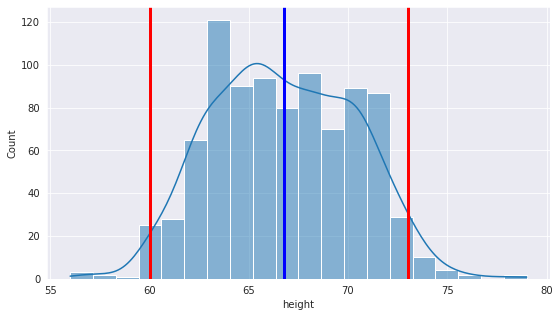

In [63]:
def plot_histo(x, ax, p=5):
    sns.histplot(x, kde=True, ax=ax)
    ax.axvline(x.mean(), c='b', linewidth=3)
    ax.axvline(np.percentile(x, p/2.), color='r', linewidth=3)
    ax.axvline(np.percentile(x, 100-p/2.), color='r', linewidth=3)
    
fig, ax = plt.subplots(figsize=(9, 5), sharex=True)
plot_histo(df.height, ax)

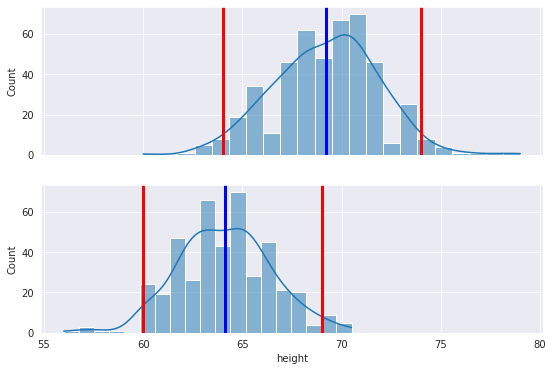

In [64]:
male = df[df.gender=="M"]
female = df[df.gender=='F']

fig, ax = plt.subplots(nrows=2, figsize=(9, 6), sharex=True)
plot_histo(male.height, ax[0])
plot_histo(female.height, ax[1])

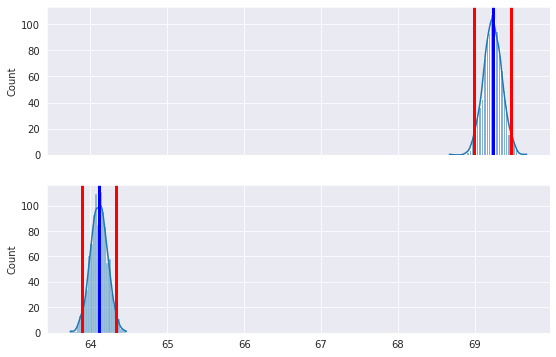

In [68]:
n_replicas = 1000

female_bootstrap_means = pd.Series([
 female.sample(frac=1, replace=True).height.mean()
 for i in range(n_replicas)])
male_bootstrap_means = pd.Series([
 male.sample(frac=1, replace=True).height.mean()
 for i in range(n_replicas)])

fig, ax = plt.subplots(nrows=2, figsize=(9, 6), sharex=True)
plot_histo(male_bootstrap_means, ax[0])
plot_histo(female_bootstrap_means, ax[1])

In [67]:
male_bootstrap_means

0      69.404946
1      69.144946
2      69.190323
3      69.107312
4      69.137419
         ...    
995    69.123011
996    69.219355
997    69.337849
998    69.233118
999    69.126452
Length: 1000, dtype: float64